In [1]:
import pandas as pd

df = pd.read_csv('PPC data  V4 - 010825-310126 (1).csv')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## Exploration

In [2]:
print(df.shape)
df.head(10)

(7878, 13)


,Lead ID,Lead Status,Premium,Age,Gender,Smoker,Current Insurance,Device Type,Keyword,Match Type,Patrial Postcode,COVER FOR,Verification Status
0,0005F412,Contacted,0.0,31,Female,Yes,no,Desktop,private health insurance belfast,Exact,Bt13,Self,NaN
1,000A5F9D,Contacted,0.0,35,Female,No,no,Smartphone,private medical insurance,Phrase,LU7,Self,NaN
2,00148A0A,Contacted,0.0,46,Male,No,yes private,Smartphone,private health insurance,Broad,E14,Self,NaN
3,002C53E5,No Contact,0.0,53,Female,No,no,Desktop,bupa health insurance,Exact,W2,Self + Partner,NaN
4,005FC597,Contacted,0.0,35,Male,No,no,Smartphone,private healthcare prices,Exact,BH23,Self,NaN
5,0065F9A5,Contacted,0.0,55,Male,No,no,Desktop,private medical insurance,Broad,CV10,Self + Family,NaN
6,00739C01,Contacted,0.0,37,Male,No,yes company,Desktop,bupa health care insurance,Exact,OX28,Self + Family,NaN
7,008B3646,Contacted,0.0,72,Male,No,no,Smartphone,private heathcare,Exact,S18,Self + Partner,NaN
8,008C07DC,Contacted,0.0,62,Male,No,no,Smartphone,bupa private health care,Exact,GL4,Self + Partner,NaN
9,00A4E420,Quoted,0.0,40,Female,No,yes private,Smartphone,private medical aid,Exact,Bt20,Self,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7878 entries, 0 to 7877
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Lead ID              7878 non-null   object 
 1   Lead Status          7878 non-null   object 
 2   Premium              7878 non-null   float64
 3   Age                  7878 non-null   int64  
 4   Gender               7878 non-null   object 
 5   Smoker               7878 non-null   object 
 6   Current Insurance    7878 non-null   object 
 7   Device Type          7878 non-null   object 
 8   Keyword              7866 non-null   object 
 9   Match Type           7859 non-null   object 
 10  Patrial Postcode     7878 non-null   object 
 11  COVER FOR            7878 non-null   object 
 12  Verification Status  1642 non-null   object 
dtypes: float64(1), int64(1), object(11)
memory usage: 800.2+ KB


- ---> Verification status null = not verified

### Unique values per column (understand cardinality)

In [4]:
# How many distinct values does each column have?
for col in df.columns:
    print(f"{col:25s} → {df[col].nunique():>5} unique")

Lead ID                   →  7878 unique
Lead Status               →     5 unique
Premium                   →   385 unique
Age                       →    76 unique
Gender                    →     2 unique
Smoker                    →     2 unique
Current Insurance         →     3 unique
Device Type               →     3 unique
Keyword                   →   270 unique
Match Type                →     3 unique
Patrial Postcode          →  3000 unique
COVER FOR                 →     3 unique
Verification Status       →     1 unique


### Value counts for every categorical column

In [5]:
# Distribution of each categorical field
cat_cols = ['Lead Status', 'Gender', 'Smoker', 'Current Insurance', 
            'Device Type', 'Match Type', 'COVER FOR', 'Verification Status']

for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


--- Lead Status ---
Lead Status
Contacted     6280
Quoted         533
Sold           386
Invalid        342
No Contact     337
Name: count, dtype: int64

--- Gender ---
Gender
Female    4212
Male      3666
Name: count, dtype: int64

--- Smoker ---
Smoker
No     7156
Yes     722
Name: count, dtype: int64

--- Current Insurance ---
Current Insurance
no             6466
yes private     999
yes company     413
Name: count, dtype: int64

--- Device Type ---
Device Type
Smartphone    5688
Desktop       1860
Tablet         330
Name: count, dtype: int64

--- Match Type ---
Match Type
Exact     5085
Phrase    1415
Broad     1359
NaN         19
Name: count, dtype: int64

--- COVER FOR ---
COVER FOR
Self              4471
Self + Family     1948
Self + Partner    1459
Name: count, dtype: int64

--- Verification Status ---
Verification Status
NaN         6236
verified    1642
Name: count, dtype: int64


In [6]:
# Premium and Age distributions
print("--- Premium ---")
print(df['Premium'].describe())
print(f"\nNon-zero premiums: {(df['Premium'] > 0).sum()}")

print("\n--- Age ---")
print(df['Age'].describe())
print(f"\nAge > 90: {(df['Age'] > 90).sum()} leads")

--- Premium ---
count    7878.000000
mean       77.305918
std       416.727282
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max      8353.200000
Name: Premium, dtype: float64

Non-zero premiums: 384

--- Age ---
count    7878.000000
mean       47.830160
std        15.933302
min        20.000000
25%        36.000000
50%        45.000000
75%        59.000000
max       119.000000
Name: Age, dtype: float64

Age > 90: 12 leads


##
----

## 1/ Data Cleaning

### Clean Verification Status

In [7]:
# Recode Verification Status: NaN means "not verified"
# This column is the single strongest signal in the dataset
df['Verified'] = df['Verification Status'].apply(lambda x: 'Verified' if x == 'verified' else 'Not Verified')

print(df['Verified'].value_counts())

Verified
Not Verified    6236
Verified        1642
Name: count, dtype: int64


### Create Age Bands

In [8]:
# Age as a continuous variable is hard to segment on
# Create bands that align with insurance pricing tiers
bins = [0, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 120]
labels = ['20-25', '26-30', '31-35', '36-40', '41-45', '46-50', 
          '51-55', '56-60', '61-65', '66-70', '71-75', '76+']

df['Age Band'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)

print(df['Age Band'].value_counts().sort_index())

Age Band
20-25     546
26-30     634
31-35     665
36-40    1089
41-45    1024
46-50     776
51-55     712
56-60     639
61-65     551
66-70     378
71-75     362
76+       502
Name: count, dtype: int64


### Normalise postcodes and extract area prefix

In [9]:
# Postcodes have inconsistent casing (BT13 vs Bt13 vs bt13)
# Extract the 1-2 letter area prefix for regional analysis
df['PC_Area'] = df['Patrial Postcode'].str.upper().str.extract(r'^([A-Z]{1,2})')[0]

print(f"Unique postcode areas: {df['PC_Area'].nunique()}")
print(df['PC_Area'].value_counts().head(10))

Unique postcode areas: 127
PC_Area
B     281
M     172
S     164
NG    163
PE    142
E     140
LE    134
SW    131
BN    129
CV    129
Name: count, dtype: int64


### Create the key flags we'll need throughout

In [10]:
# Binary sale flag (1 = Sold, 0 = everything else)
df['is_sold'] = (df['Lead Status'] == 'Sold').astype(int)

# Binary invalid flag
df['is_invalid'] = (df['Lead Status'] == 'Invalid').astype(int)

# Quick sanity check
print(f"Total leads:  {len(df)}")
print(f"Total sales:  {df['is_sold'].sum()}")
print(f"Total invalid: {df['is_invalid'].sum()}")
print(f"Conv rate:     {df['is_sold'].mean():.2%}")

Total leads:  7878
Total sales:  386
Total invalid: 342
Conv rate:     4.90%


##
----

## 2/ Commercial Analysis

### Top-line commercial summary (the baseline everything is measured against)

In [11]:
# Constants from the brief
COST_PER_LEAD = 55

# Core metrics
total_leads = len(df)
total_sold = df['is_sold'].sum()
total_revenue = df['Premium'].sum()
total_cost = total_leads * COST_PER_LEAD

print("=== TOP-LINE COMMERCIAL SUMMARY ===")
print(f"Total leads:       {total_leads:,}")
print(f"Total sales:       {total_sold}")
print(f"Conversion rate:   {total_sold / total_leads:.2%}")
print(f"Total revenue:     £{total_revenue:,.2f}")
print(f"Total lead cost:   £{total_cost:,.2f}")
print(f"Net P&L:           £{total_revenue - total_cost:,.2f}")
print(f"RPL:               £{total_revenue / total_leads:.2f}")
print(f"Avg commission:    £{df[df['is_sold']==1]['Premium'].mean():.2f}")
print(f"Median commission: £{df[df['is_sold']==1]['Premium'].median():.2f}")
print(f"Client ROI:        {(total_revenue - total_cost) / total_cost * 100:.1f}%")

=== TOP-LINE COMMERCIAL SUMMARY ===
Total leads:       7,878
Total sales:       386
Conversion rate:   4.90%
Total revenue:     £609,016.02
Total lead cost:   £433,290.00
Net P&L:           £175,726.02
RPL:               £77.31
Avg commission:    £1540.12
Median commission: £1285.80
Client ROI:        40.6%


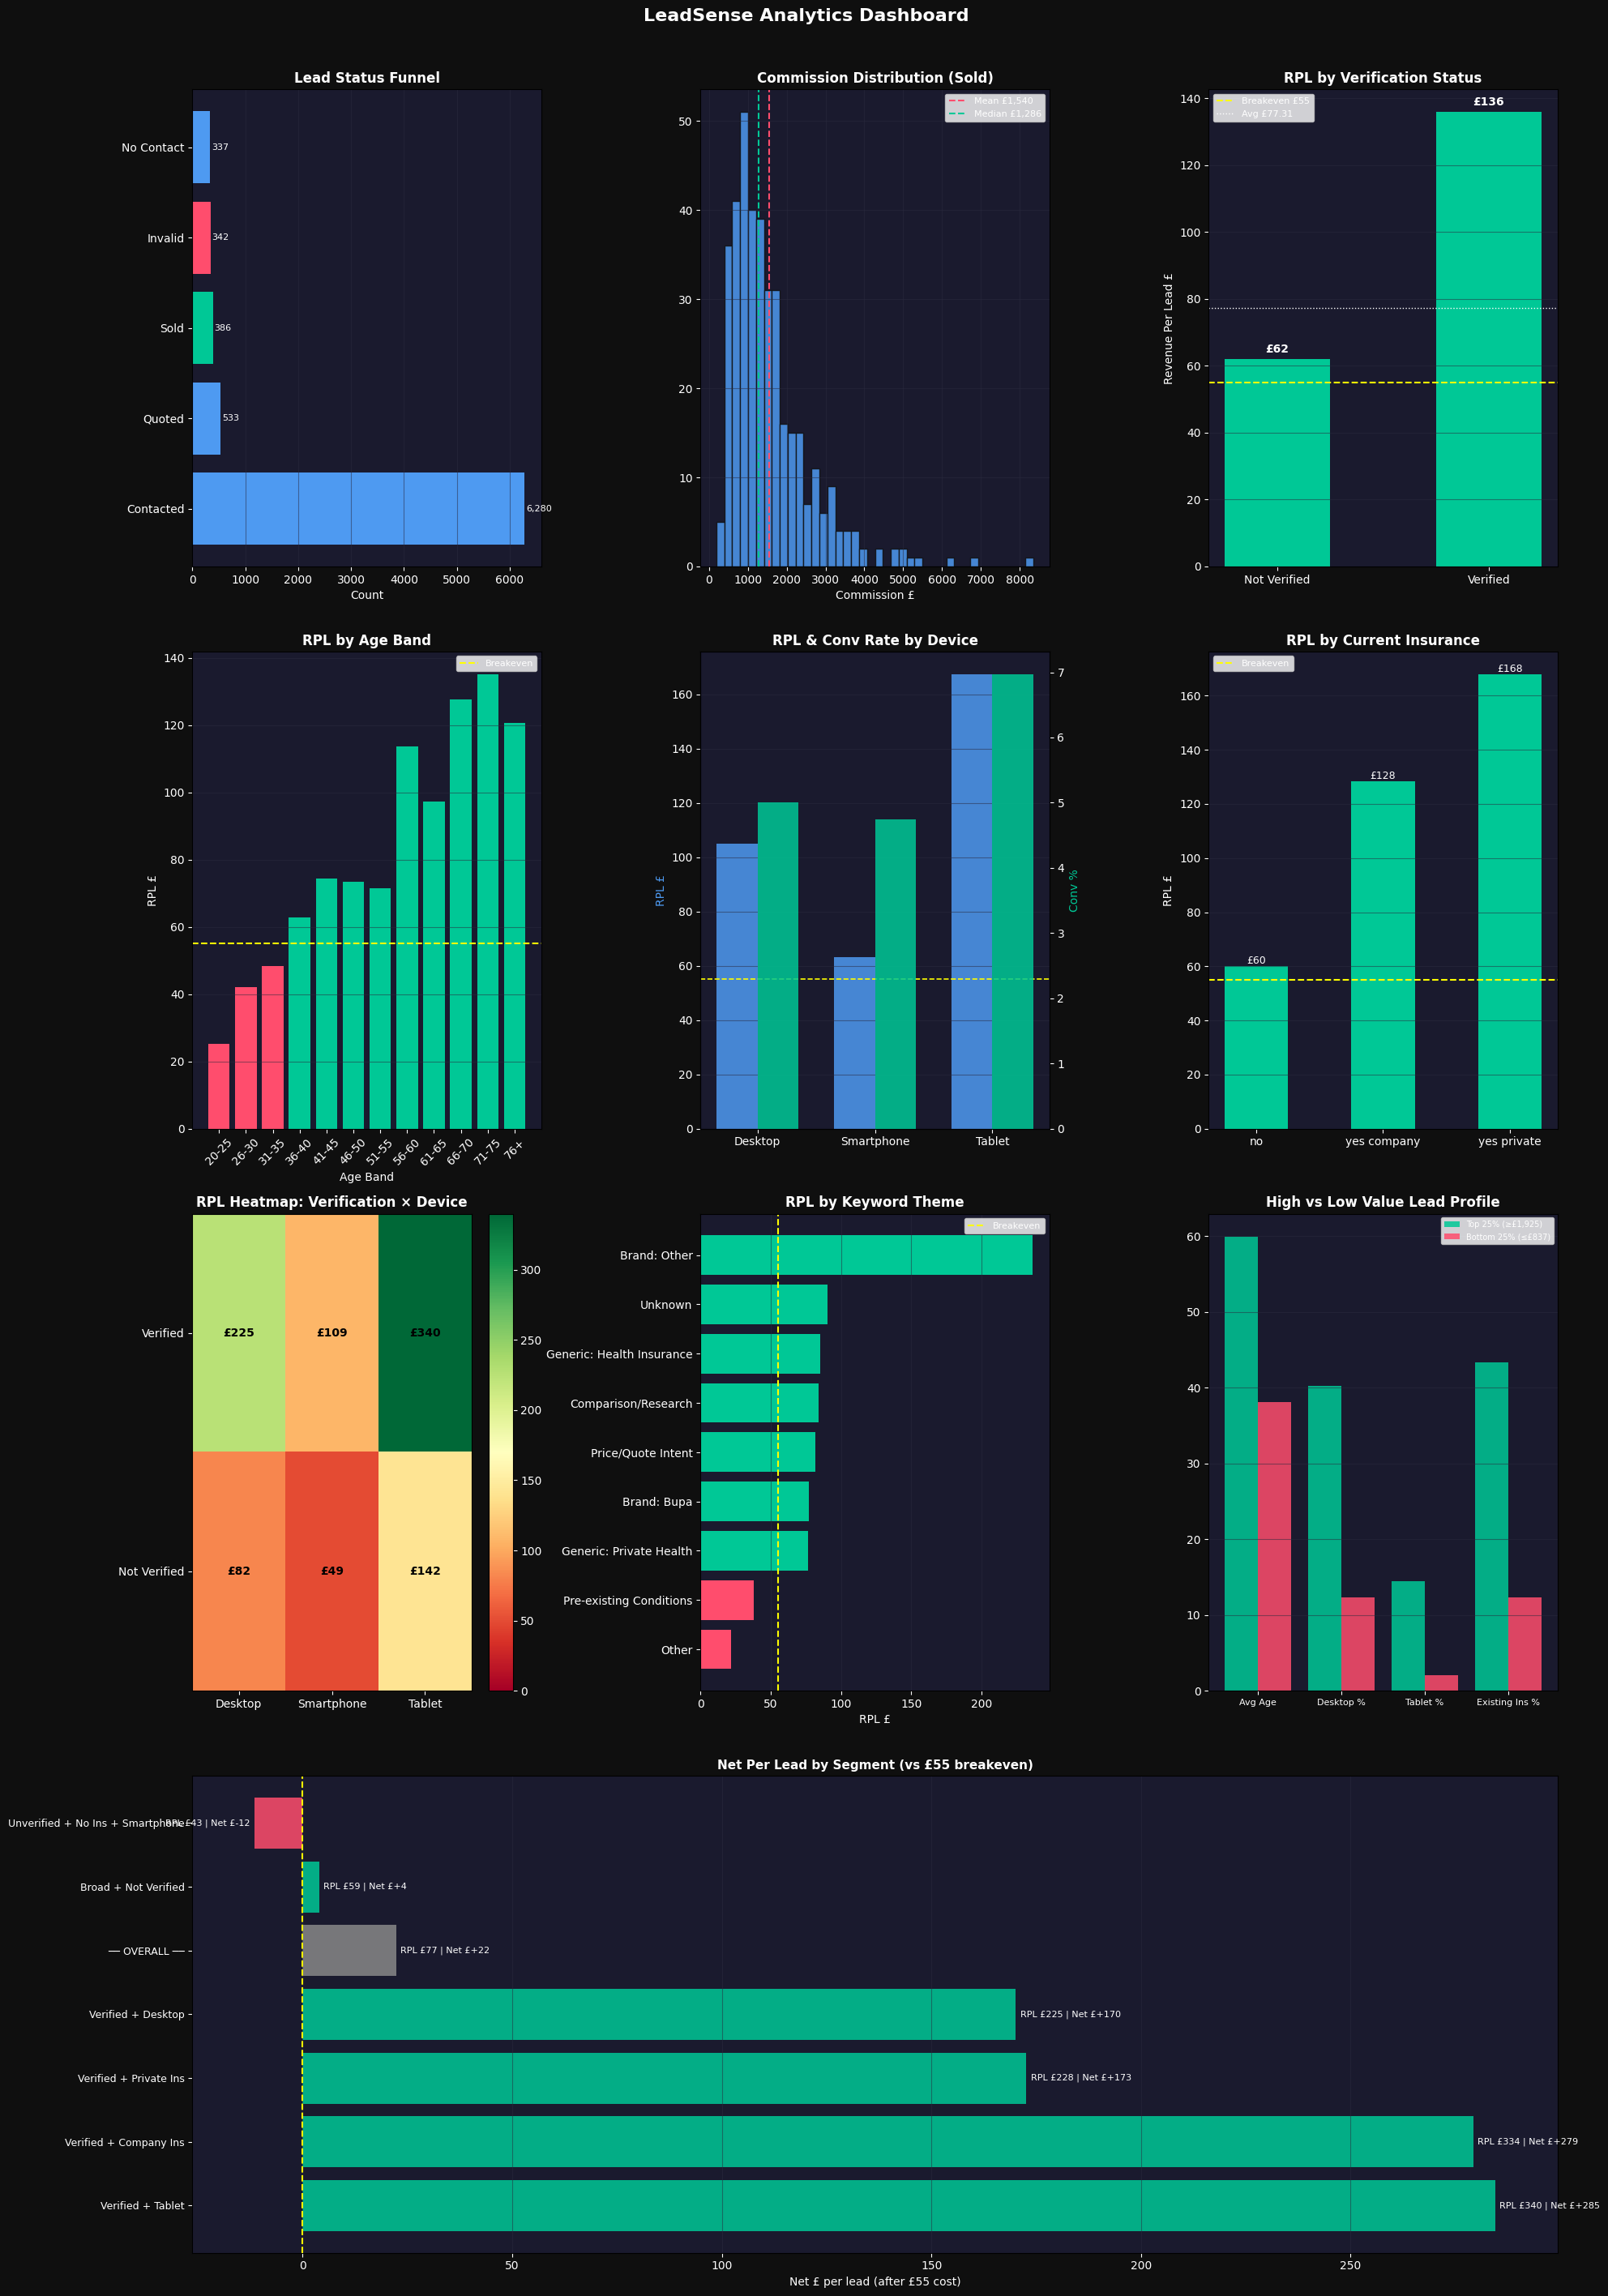

In [28]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

fig = plt.figure(figsize=(20, 28))
fig.patch.set_facecolor('#0f0f0f')
plt.rcParams.update({'text.color': 'white', 'axes.labelcolor': 'white',
                     'xtick.color': 'white', 'ytick.color': 'white'})

PROFITABLE = '#00c896'
LOSS = '#ff4d6d'
NEUTRAL = '#4e9af1'
BG = '#1a1a2e'
GRID = '#2a2a3e'

# ── 1. FUNNEL ──────────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(4, 3, 1)
ax1.set_facecolor(BG)
statuses = df['Lead Status'].value_counts()
colors = [PROFITABLE if s == 'Sold' else LOSS if s == 'Invalid' else NEUTRAL for s in statuses.index]
bars = ax1.barh(statuses.index, statuses.values, color=colors)
ax1.set_title('Lead Status Funnel', color='white', fontweight='bold')
ax1.set_xlabel('Count')
for bar, val in zip(bars, statuses.values):
    ax1.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', color='white', fontsize=8)
ax1.grid(axis='x', color=GRID, alpha=0.5)

# ── 2. COMMISSION DISTRIBUTION ────────────────────────────────────────────────
ax2 = fig.add_subplot(4, 3, 2)
ax2.set_facecolor(BG)
sold_premiums = df[df['is_sold'] == 1]['Premium']
ax2.hist(sold_premiums[sold_premiums > 0], bins=40, color=NEUTRAL, edgecolor='#0f0f0f', alpha=0.85)
ax2.axvline(sold_premiums.mean(), color=LOSS, linestyle='--', linewidth=1.5, label=f'Mean £{sold_premiums.mean():,.0f}')
ax2.axvline(sold_premiums.median(), color=PROFITABLE, linestyle='--', linewidth=1.5, label=f'Median £{sold_premiums.median():,.0f}')
ax2.set_title('Commission Distribution (Sold)', color='white', fontweight='bold')
ax2.set_xlabel('Commission £')
ax2.legend(fontsize=8)
ax2.grid(color=GRID, alpha=0.5)

# ── 3. RPL BY VERIFICATION ────────────────────────────────────────────────────
ax3 = fig.add_subplot(4, 3, 3)
ax3.set_facecolor(BG)
ver_data = df.groupby('Verified').agg(rpl=('Premium', lambda x: x.sum() / len(x))).reset_index()
bar_colors = [PROFITABLE if r > 55 else LOSS for r in ver_data['rpl']]
bars = ax3.bar(ver_data['Verified'], ver_data['rpl'], color=bar_colors, width=0.5)
ax3.axhline(55, color='yellow', linestyle='--', linewidth=1.5, label='Breakeven £55')
ax3.axhline(77.31, color='white', linestyle=':', linewidth=1, label='Avg £77.31')
ax3.set_title('RPL by Verification Status', color='white', fontweight='bold')
ax3.set_ylabel('Revenue Per Lead £')
ax3.legend(fontsize=8)
for bar, val in zip(bars, ver_data['rpl']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'£{val:.0f}', ha='center', color='white', fontsize=10, fontweight='bold')
ax3.grid(axis='y', color=GRID, alpha=0.5)

# ── 4. AGE BAND ANALYSIS ──────────────────────────────────────────────────────
ax4 = fig.add_subplot(4, 3, 4)
ax4.set_facecolor(BG)
age_data = []
for band in labels:
    subset = df[df['Age Band'] == band]
    n = len(subset)
    rpl = subset['Premium'].sum() / n if n > 0 else 0
    age_data.append({'band': band, 'rpl': rpl, 'n': n})
age_df = pd.DataFrame(age_data)
bar_colors = [PROFITABLE if r > 55 else LOSS for r in age_df['rpl']]
bars = ax4.bar(age_df['band'], age_df['rpl'], color=bar_colors)
ax4.axhline(55, color='yellow', linestyle='--', linewidth=1.5, label='Breakeven')
ax4.set_title('RPL by Age Band', color='white', fontweight='bold')
ax4.set_xlabel('Age Band')
ax4.set_ylabel('RPL £')
ax4.tick_params(axis='x', rotation=45)
ax4.legend(fontsize=8)
ax4.grid(axis='y', color=GRID, alpha=0.5)

# ── 5. DEVICE TYPE ────────────────────────────────────────────────────────────
ax5 = fig.add_subplot(4, 3, 5)
ax5.set_facecolor(BG)
dev = df.groupby('Device Type').agg(
    rpl=('Premium', lambda x: x.sum() / len(x)),
    conv=('is_sold', 'mean'),
    n=('Lead ID', 'count')
).reset_index()
x = np.arange(len(dev))
width = 0.35
ax5_twin = ax5.twinx()
ax5.bar(x - width/2, dev['rpl'], width, color=NEUTRAL, label='RPL £', alpha=0.85)
ax5_twin.bar(x + width/2, dev['conv'] * 100, width, color=PROFITABLE, label='Conv %', alpha=0.85)
ax5.axhline(55, color='yellow', linestyle='--', linewidth=1.2)
ax5.set_title('RPL & Conv Rate by Device', color='white', fontweight='bold')
ax5.set_xticks(x)
ax5.set_xticklabels(dev['Device Type'])
ax5.set_ylabel('RPL £', color=NEUTRAL)
ax5_twin.set_ylabel('Conv %', color=PROFITABLE)
ax5_twin.tick_params(colors='white')
ax5.grid(axis='y', color=GRID, alpha=0.5)

# ── 6. CURRENT INSURANCE ─────────────────────────────────────────────────────
ax6 = fig.add_subplot(4, 3, 6)
ax6.set_facecolor(BG)
ci = df.groupby('Current Insurance').agg(
    rpl=('Premium', lambda x: x.sum() / len(x)),
    n=('Lead ID', 'count')
).reset_index()
bar_colors = [PROFITABLE if r > 55 else LOSS for r in ci['rpl']]
bars = ax6.bar(ci['Current Insurance'], ci['rpl'], color=bar_colors, width=0.5)
ax6.axhline(55, color='yellow', linestyle='--', linewidth=1.5, label='Breakeven')
ax6.set_title('RPL by Current Insurance', color='white', fontweight='bold')
ax6.set_ylabel('RPL £')
ax6.legend(fontsize=8)
for bar, val in zip(bars, ci['rpl']):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'£{val:.0f}', ha='center', color='white', fontsize=9)
ax6.grid(axis='y', color=GRID, alpha=0.5)

# ── 7. VERIFICATION × DEVICE HEATMAP ─────────────────────────────────────────
ax7 = fig.add_subplot(4, 3, 7)
ax7.set_facecolor(BG)
devices = ['Desktop', 'Smartphone', 'Tablet']
verified = ['Verified', 'Not Verified']
matrix = np.array([
    [df[(df['Verified']==v) & (df['Device Type']==d)]['Premium'].sum() /
     max(len(df[(df['Verified']==v) & (df['Device Type']==d)]), 1)
     for d in devices] for v in verified
])
im = ax7.imshow(matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=340)
ax7.set_xticks(range(len(devices)))
ax7.set_yticks(range(len(verified)))
ax7.set_xticklabels(devices)
ax7.set_yticklabels(verified)
ax7.set_title('RPL Heatmap: Verification × Device', color='white', fontweight='bold')
for i in range(len(verified)):
    for j in range(len(devices)):
        ax7.text(j, i, f'£{matrix[i,j]:.0f}', ha='center', va='center',
                 color='black', fontweight='bold', fontsize=10)
plt.colorbar(im, ax=ax7)

# ── 8. KEYWORD THEME ─────────────────────────────────────────────────────────
ax8 = fig.add_subplot(4, 3, 8)
ax8.set_facecolor(BG)
theme_data = df.groupby('KW_Theme').agg(
    rpl=('Premium', lambda x: x.sum() / len(x)),
    n=('Lead ID', 'count')
).reset_index().sort_values('rpl', ascending=True)
bar_colors = [PROFITABLE if r > 55 else LOSS for r in theme_data['rpl']]
bars = ax8.barh(theme_data['KW_Theme'], theme_data['rpl'], color=bar_colors)
ax8.axvline(55, color='yellow', linestyle='--', linewidth=1.5, label='Breakeven')
ax8.set_title('RPL by Keyword Theme', color='white', fontweight='bold')
ax8.set_xlabel('RPL £')
ax8.legend(fontsize=8)
ax8.grid(axis='x', color=GRID, alpha=0.5)

# ── 9. HIGH vs LOW VALUE PROFILE ─────────────────────────────────────────────
ax9 = fig.add_subplot(4, 3, 9)
ax9.set_facecolor(BG)
sold_df = df[df['is_sold'] == 1].copy()
q75 = sold_df['Premium'].quantile(0.75)
q25 = sold_df['Premium'].quantile(0.25)
high_val = sold_df[sold_df['Premium'] >= q75]
low_val = sold_df[sold_df['Premium'] <= q25]
metrics = ['Avg Age', 'Desktop %', 'Tablet %', 'Existing Ins %']
high_vals = [
    high_val['Age'].mean(),
    (high_val['Device Type'] == 'Desktop').mean() * 100,
    (high_val['Device Type'] == 'Tablet').mean() * 100,
    (high_val['Current Insurance'] != 'no').mean() * 100,
]
low_vals = [
    low_val['Age'].mean(),
    (low_val['Device Type'] == 'Desktop').mean() * 100,
    (low_val['Device Type'] == 'Tablet').mean() * 100,
    (low_val['Current Insurance'] != 'no').mean() * 100,
]
x = np.arange(len(metrics))
ax9.bar(x - 0.2, high_vals, 0.4, label=f'Top 25% (≥£{q75:,.0f})', color=PROFITABLE, alpha=0.85)
ax9.bar(x + 0.2, low_vals, 0.4, label=f'Bottom 25% (≤£{q25:,.0f})', color=LOSS, alpha=0.85)
ax9.set_title('High vs Low Value Lead Profile', color='white', fontweight='bold')
ax9.set_xticks(x)
ax9.set_xticklabels(metrics, fontsize=8)
ax9.legend(fontsize=7)
ax9.grid(axis='y', color=GRID, alpha=0.5)

# ── 10. SEGMENT RANKING ───────────────────────────────────────────────────────
ax10 = fig.add_subplot(4, 3, (10, 12))
ax10.set_facecolor(BG)
seg_names = [
    'Verified + Tablet',
    'Verified + Company Ins',
    'Verified + Private Ins',
    'Verified + Desktop',
    '── OVERALL ──',
    'Broad + Not Verified',
    'Unverified + No Ins + Smartphone',
]
seg_subsets = [
    df[(df['Verified']=='Verified') & (df['Device Type']=='Tablet')],
    df[(df['Verified']=='Verified') & (df['Current Insurance']=='yes company')],
    df[(df['Verified']=='Verified') & (df['Current Insurance']=='yes private')],
    df[(df['Verified']=='Verified') & (df['Device Type']=='Desktop')],
    df,
    df[(df['Match Type']=='Broad') & (df['Verified']=='Not Verified')],
    df[(df['Verified']=='Not Verified') & (df['Current Insurance']=='no') & (df['Device Type']=='Smartphone')],
]
rpls = [s['Premium'].sum() / len(s) for s in seg_subsets]
nets = [r - 55 for r in rpls]
bar_colors = [PROFITABLE if n > 0 else LOSS for n in nets]
bar_colors[4] = '#888'  # overall = grey
y = np.arange(len(seg_names))
bars = ax10.barh(y, nets, color=bar_colors, alpha=0.85)
ax10.axvline(0, color='yellow', linewidth=1.5, linestyle='--')
ax10.set_yticks(y)
ax10.set_yticklabels(seg_names, fontsize=9)
ax10.set_title('Net Per Lead by Segment (vs £55 breakeven)', color='white', fontweight='bold', fontsize=11)
ax10.set_xlabel('Net £ per lead (after £55 cost)')
for bar, net, rpl in zip(bars, nets, rpls):
    xpos = bar.get_width() + 1 if net >= 0 else bar.get_width() - 1
    ha = 'left' if net >= 0 else 'right'
    ax10.text(xpos, bar.get_y() + bar.get_height()/2,
              f'RPL £{rpl:.0f} | Net £{net:+.0f}', va='center', ha=ha, color='white', fontsize=8)
ax10.grid(axis='x', color=GRID, alpha=0.5)

plt.suptitle('LeadSense Analytics Dashboard', fontsize=16, fontweight='bold',
             color='white', y=1.01)
plt.tight_layout()
plt.show()

### Lead status funnel breakdown

In [12]:
# Revenue and RPL by each status
print("=== LEAD STATUS FUNNEL ===\n")
for status in df['Lead Status'].value_counts().index:
    subset = df[df['Lead Status'] == status]
    n = len(subset)
    rev = subset['Premium'].sum()
    rpl = rev / n
    print(f"{status:15s} | {n:5,} leads ({n/total_leads:5.1%}) | Revenue: £{rev:>10,.2f} | RPL: £{rpl:.2f}")

=== LEAD STATUS FUNNEL ===

Contacted       | 6,280 leads (79.7%) | Revenue: £      0.00 | RPL: £0.00
Quoted          |   533 leads ( 6.8%) | Revenue: £ 14,531.28 | RPL: £27.26
Sold            |   386 leads ( 4.9%) | Revenue: £594,484.74 | RPL: £1540.12
Invalid         |   342 leads ( 4.3%) | Revenue: £      0.00 | RPL: £0.00
No Contact      |   337 leads ( 4.3%) | Revenue: £      0.00 | RPL: £0.00


###  Commission distribution for sold leads (understand the value spread)

In [13]:
# What does the commission distribution look like?
sold = df[df['is_sold'] == 1]['Premium']

print("=== COMMISSION DISTRIBUTION (Sold Leads Only) ===\n")
print(f"Count:  {len(sold)}")
print(f"Mean:   £{sold.mean():,.2f}")
print(f"Median: £{sold.median():,.2f}")
print(f"Min:    £{sold.min():,.2f}")
print(f"25th:   £{sold.quantile(0.25):,.2f}")
print(f"75th:   £{sold.quantile(0.75):,.2f}")
print(f"90th:   £{sold.quantile(0.90):,.2f}")
print(f"Max:    £{sold.max():,.2f}")
print(f"\nSold with £0 premium: {(sold == 0).sum()}")

=== COMMISSION DISTRIBUTION (Sold Leads Only) ===

Count:  386
Mean:   £1,540.12
Median: £1,285.80
Min:    £0.00
25th:   £836.73
75th:   £1,924.92
90th:   £2,886.42
Max:    £8,353.20

Sold with £0 premium: 8


### Interpretation: Commercial Baseline

**The client (the insurance buyer) is profitable overall.** At £77.31 RPL against a £55 cost per lead, the client nets £22.31 per lead — a 40.6% ROI. Over 7,878 leads, that's £175,726 in net profit.

**But the average hides a highly skewed distribution.** The median commission (£1,286) is meaningfully lower than the mean (£1,540), and the spread is enormous — from £0 to £8,353. The top 10% of sales (≥£2,886) are worth 3.4× the bottom 25% (≤£837). This tells us not all sales are equal — understanding WHICH leads produce high-value sales is critical.

**The funnel has a massive bottleneck.** 79.7% of leads (6,280) stall at "Contacted" and never progress. Only 4.9% convert to a sale. The combined Invalid + No Contact rate of 8.6% (679 leads = £37,345 in wasted lead cost) represents pure loss with zero revenue potential.

**The 8 "Sold" leads with £0 premium are anomalies** — likely cancellations or data lag. The 6 "Quoted" leads carrying £14,531 in premium are also unusual — they suggest revenue is sometimes attributed before a sale is finalised.

**Key baseline numbers to remember going forward:**
- RPL benchmark: **£77.31** (any segment above this is outperforming)
- Breakeven threshold: **£55** (any segment below this is unprofitable)
- Conversion rate benchmark: **4.90%**
- Average commission benchmark: **£1,540**

##
----

## 3/ dimensional breakdowns

In [14]:
# Simple function to analyse any column
def analyse_dimension(col_name):
    print(f"\n=== {col_name.upper()} ===\n")
    print(f"{'Value':25s} | {'Leads':>6s} | {'Sales':>5s} | {'Conv%':>5s} | {'RPL':>8s} | {'Avg Comm':>9s} | {'Invalid%':>7s} | {'Net/Lead':>9s}")
    print("-" * 100)
    
    for val in df[col_name].dropna().unique():
        subset = df[df[col_name] == val]
        n = len(subset)
        sales = subset['is_sold'].sum()
        rev = subset['Premium'].sum()
        cr = sales / n
        rpl = rev / n
        inv = subset['is_invalid'].mean()
        avg_comm = subset[subset['is_sold']==1]['Premium'].mean() if sales > 0 else 0
        net = rpl - COST_PER_LEAD
        
        flag = "  ✓" if net > 0 else "  ✗"
        print(f"{str(val):25s} | {n:>6,} | {sales:>5} | {cr:>5.1%} | £{rpl:>7.2f} | £{avg_comm:>8.2f} | {inv:>6.1%} | £{net:>7.2f}{flag}")

analyse_dimension('Verified')


=== VERIFIED ===

Value                     |  Leads | Sales | Conv% |      RPL |  Avg Comm | Invalid% |  Net/Lead
----------------------------------------------------------------------------------------------------
Not Verified              |  6,236 |   230 |  3.7% | £  61.90 | £ 1624.32 |   5.2% | £   6.90  ✓
Verified                  |  1,642 |   156 |  9.5% | £ 135.81 | £ 1415.97 |   1.0% | £  80.81  ✓


In [15]:
analyse_dimension('Device Type')


=== DEVICE TYPE ===

Value                     |  Leads | Sales | Conv% |      RPL |  Avg Comm | Invalid% |  Net/Lead
----------------------------------------------------------------------------------------------------
Desktop                   |  1,860 |    93 |  5.0% | £ 104.98 | £ 2060.57 |   5.6% | £  49.98  ✓
Smartphone                |  5,688 |   270 |  4.7% | £  63.03 | £ 1287.45 |   3.8% | £   8.03  ✓
Tablet                    |    330 |    23 |  7.0% | £ 167.40 | £ 2401.78 |   5.8% | £ 112.40  ✓


In [16]:
analyse_dimension('Current Insurance')


=== CURRENT INSURANCE ===

Value                     |  Leads | Sales | Conv% |      RPL |  Avg Comm | Invalid% |  Net/Lead
----------------------------------------------------------------------------------------------------
no                        |  6,466 |   285 |  4.4% | £  60.05 | £ 1336.30 |   4.2% | £   5.05  ✓
yes private               |    999 |    80 |  8.0% | £ 167.94 | £ 2008.31 |   4.7% | £ 112.94  ✓
yes company               |    413 |    21 |  5.1% | £ 128.27 | £ 2522.64 |   5.6% | £  73.27  ✓


In [17]:
analyse_dimension('Match Type')
analyse_dimension('COVER FOR')
analyse_dimension('Smoker')
analyse_dimension('Gender')


=== MATCH TYPE ===

Value                     |  Leads | Sales | Conv% |      RPL |  Avg Comm | Invalid% |  Net/Lead
----------------------------------------------------------------------------------------------------
Exact                     |  5,085 |   260 |  5.1% | £  76.14 | £ 1455.39 |   4.0% | £  21.14  ✓
Phrase                    |  1,415 |    86 |  6.1% | £  97.58 | £ 1538.78 |   4.5% | £  42.58  ✓
Broad                     |  1,359 |    39 |  2.9% | £  60.82 | £ 2119.51 |   5.3% | £   5.82  ✓

=== COVER FOR ===

Value                     |  Leads | Sales | Conv% |      RPL |  Avg Comm | Invalid% |  Net/Lead
----------------------------------------------------------------------------------------------------
Self                      |  4,471 |   206 |  4.6% | £  60.52 | £ 1271.74 |   4.5% | £   5.52  ✓
Self + Partner            |  1,459 |    64 |  4.4% | £ 106.86 | £ 2343.72 |   4.7% | £  51.86  ✓
Self + Family             |  1,948 |   116 |  6.0% | £  93.69 | £ 1573.35 |   

### Interpretation: Dimensional Breakdowns

**Three dimensions stand out as strong commercial drivers. The rest are weak.**

**Tier 1 — Strong drivers (act on these):**

1. **Verification** — The single biggest lever. Verified leads: 9.5% conv, £135.81 RPL. Unverified: 3.7%, £61.90. That's 2.2× the RPL. Also slashes invalid rate from 5.2% to 1.0%. Note: avg commission is actually *lower* for verified (£1,416 vs £1,624) — the value comes entirely from the much higher conversion rate.

2. **Current Insurance** — Already having private insurance: 8.0% conv, £167.94 RPL, £2,008 avg commission. No insurance: 4.4%, £60.05, £1,336. These leads know the product and are likely switching — they convert more AND are worth more per sale. Company insurance is interesting: lower conversion (5.1%) but the highest avg commission of all (£2,523) — high earners switching from employer cover.

3. **Device Type** — Tablet: 7.0% conv, £167.40 RPL, £2,402 avg commission. Desktop: 5.0%, £104.98. Smartphone: 4.7%, £63.03. Smartphone is 72% of volume but generates the lowest value. Tablet users are in deliberate "research and buy" mode.

**Tier 2 — Moderate drivers:**

4. **Match Type** — Phrase outperforms (6.1%, £97.58 RPL). Broad is weakest (2.9%, £60.82). Broad barely breaks even at £5.82 net/lead.

5. **Cover For** — Self + Family has best conv (6.0%), Self + Partner has best avg commission (£2,344). Self-only is weakest on both.

**Tier 3 — Weak/negligible drivers:**

6. **Smoker** — Small difference. Non-smokers slightly better (£78 vs £66 RPL) but not a major lever.

7. **Gender** — Nearly identical. Male £79.89, Female £75.06. Not actionable.

##
----

## 4/ Age Band analysis and Keyword analysis

### Age Band breakdown

In [18]:
# Age bands need sorting, so we handle slightly differently
print("=== AGE BAND ===\n")
print(f"{'Age Band':>10s} | {'Leads':>6s} | {'Sales':>5s} | {'Conv%':>6s} | {'RPL':>9s} | {'Avg Comm':>10s} | {'Net/Lead':>9s}")
print("-" * 80)

for band in labels:  # labels defined earlier, already in order
    subset = df[df['Age Band'] == band]
    n = len(subset)
    sales = subset['is_sold'].sum()
    rev = subset['Premium'].sum()
    cr = sales / n if n > 0 else 0
    rpl = rev / n if n > 0 else 0
    avg_comm = subset[subset['is_sold']==1]['Premium'].mean() if sales > 0 else 0
    net = rpl - COST_PER_LEAD
    flag = "  ✓" if net > 0 else "  ✗"
    print(f"{band:>10s} | {n:>6,} | {sales:>5} | {cr:>5.1%} | £{rpl:>7.2f} | £{avg_comm:>8.2f} | £{net:>7.2f}{flag}")

=== AGE BAND ===

  Age Band |  Leads | Sales |  Conv% |       RPL |   Avg Comm |  Net/Lead
--------------------------------------------------------------------------------
     20-25 |    546 |    20 |  3.7% | £  25.23 | £  688.87 | £ -29.77  ✗
     26-30 |    634 |    31 |  4.9% | £  42.03 | £  859.53 | £ -12.97  ✗
     31-35 |    665 |    32 |  4.8% | £  48.34 | £  982.35 | £  -6.66  ✗
     36-40 |  1,089 |    53 |  4.9% | £  62.84 | £ 1291.11 | £   7.84  ✓
     41-45 |  1,024 |    52 |  5.1% | £  74.48 | £ 1443.70 | £  19.48  ✓
     46-50 |    776 |    39 |  5.0% | £  73.45 | £ 1461.40 | £  18.45  ✓
     51-55 |    712 |    35 |  4.9% | £  71.44 | £ 1453.19 | £  16.44  ✓
     56-60 |    639 |    41 |  6.4% | £ 113.57 | £ 1746.50 | £  58.57  ✓
     61-65 |    551 |    29 |  5.3% | £  97.36 | £ 1849.86 | £  42.36  ✓
     66-70 |    378 |    18 |  4.8% | £ 127.58 | £ 2562.02 | £  72.58  ✓
     71-75 |    362 |    15 |  4.1% | £ 135.11 | £ 2866.25 | £  80.11  ✓
       76+ |    502 |   

### Top keywords by volume with performance

In [19]:
# Keyword analysis: top 20 by lead volume
kw = df.groupby('Keyword').agg(
    leads=('Lead ID', 'count'),
    sales=('is_sold', 'sum'),
    revenue=('Premium', 'sum')
).reset_index()

kw['conv_rate'] = kw['sales'] / kw['leads']
kw['rpl'] = kw['revenue'] / kw['leads']
kw['net'] = kw['rpl'] - COST_PER_LEAD

print("=== TOP 20 KEYWORDS BY VOLUME ===\n")
top20 = kw.sort_values('leads', ascending=False).head(20)

for _, row in top20.iterrows():
    flag = "✓" if row['net'] > 0 else "✗"
    print(f"  {row['Keyword'][:50]:50s} | {row['leads']:>4} leads | {row['conv_rate']:>5.1%} | RPL £{row['rpl']:>7.2f} | Net £{row['net']:>7.2f} {flag}")

=== TOP 20 KEYWORDS BY VOLUME ===

  private healthcare                                 | 1326 leads |  5.9% | RPL £  82.85 | Net £  27.85 ✓
  private medical insurance                          |  836 leads |  5.0% | RPL £  89.42 | Net £  34.42 ✓
  bupa health insurance                              |  775 leads |  6.1% | RPL £  87.61 | Net £  32.61 ✓
  bupa private health                                |  524 leads |  4.4% | RPL £  63.91 | Net £   8.91 ✓
  private medical insurance uk                       |  414 leads |  6.0% | RPL £  76.37 | Net £  21.37 ✓
  private health care                                |  262 leads |  6.1% | RPL £  80.09 | Net £  25.09 ✓
  private health insurance                           |  243 leads |  3.3% | RPL £  38.11 | Net £ -16.89 ✗
  health insurance quotes                            |  242 leads |  3.3% | RPL £  70.12 | Net £  15.12 ✓
  health insurance uk                                |  228 leads |  7.9% | RPL £ 131.49 | Net £  76.49 ✓
  health in

### Zero-sale keywords (immediate waste)

In [20]:
# Keywords with zero sales and meaningful volume
zero_sales = kw[(kw['sales'] == 0) & (kw['leads'] >= 20)].sort_values('leads', ascending=False)

print("=== ZERO-SALE KEYWORDS (≥20 leads, zero conversions) ===\n")
total_wasted = 0
for _, row in zero_sales.iterrows():
    waste = row['leads'] * COST_PER_LEAD
    total_wasted += waste
    print(f"  {row['Keyword'][:55]:55s} | {row['leads']:>3} leads | £{waste:,.0f} wasted")

print(f"\n  TOTAL: {zero_sales['leads'].sum()} leads, £{total_wasted:,.0f} wasted spend")

=== ZERO-SALE KEYWORDS (≥20 leads, zero conversions) ===

  private medical insurance policy                        |  68 leads | £3,740 wasted
  health insurance for people with pre existing cond      |  45 leads | £2,475 wasted
  medical shield insurance                                |  40 leads | £2,200 wasted
  health insurance for pre existing conditions            |  26 leads | £1,430 wasted

  TOTAL: 179 leads, £9,845 wasted spend


### Interpretation: Age & Keywords

**Age is a powerful value driver, but through commission size, not conversion rate.**

Conversion rates are surprisingly flat across age bands (3.7%–6.4%), but commission values scale dramatically: a 71-75 year old sale averages £2,866 vs £689 for a 20-25 year old — a 4.2× difference. This makes sense: older people pay higher insurance premiums, and broker commission is a percentage of the premium.

- **Under-35 leads are unprofitable** — all three bands (20-25, 26-30, 31-35) have negative net/lead. Combined: 1,845 leads losing roughly £50k.
- **56-60 is the sweet spot** — highest conversion rate (6.4%) AND strong commission (£1,747). Best balance of volume and quality.
- **66+ leads are the highest RPL** but with lower conversion rates (~4%). They convert less often but when they do, the commissions are huge (£2,500–£2,866).

**Keywords: a handful of high-volume terms drive the business.**

The top 3 keywords alone ("private healthcare", "private medical insurance", "bupa health insurance") account for ~2,937 leads (37% of total) and are all profitable. Key callouts:

- **"health insurance uk"** is a standout: 228 leads, 7.9% conv, £131 RPL — strong performer.
- **"health insurance cover"** is a problem: 168 leads, 0.6% conv, £8.44 RPL — nearly total waste (£46.56 loss per lead).
- **"private health insurance"** (243 leads) is unprofitable despite its generic appeal — only 3.3% conv, -£16.89 net. Subtle but different from "private healthcare" which performs well.
- **"best health insurance"** (115 leads) barely converts at 0.9% — comparison-intent without purchase-readiness.

**Zero-sale keywords: £9,845 in immediate recoverable waste.**

4 keywords with ≥20 leads and literally zero sales. "Medical shield insurance" is notable — 40 leads searching for a specific brand that apparently doesn't convert through this client at all. These can be paused tomorrow.

##
----

## 5/ cross-dimensional analysis and keyword clustering

### Keyword theme clustering

In [21]:
# Group 270 keywords into commercial themes
def categorize_keyword(kw):
    if pd.isna(kw):
        return 'Unknown'
    kw = kw.lower()
    if 'bupa' in kw:
        return 'Brand: Bupa'
    elif any(b in kw for b in ['axa', 'aviva', 'vitality', 'saga']):
        return 'Brand: Other'
    elif 'pre existing' in kw or 'preexisting' in kw:
        return 'Pre-existing Conditions'
    elif any(p in kw for p in ['quote', 'price', 'cost', 'cheap', 'how much', 'afford']):
        return 'Price/Quote Intent'
    elif any(c in kw for c in ['compare', 'best', 'review']):
        return 'Comparison/Research'
    elif 'private health' in kw or 'private medical' in kw or 'private healthcare' in kw:
        return 'Generic: Private Health'
    elif 'health insurance' in kw or 'medical insurance' in kw or 'healthcare insurance' in kw:
        return 'Generic: Health Insurance'
    else:
        return 'Other'

df['KW_Theme'] = df['Keyword'].apply(categorize_keyword)

# Analyse each theme
theme = df.groupby('KW_Theme').agg(
    leads=('Lead ID', 'count'),
    sales=('is_sold', 'sum'),
    revenue=('Premium', 'sum')
).reset_index()

theme['conv_rate'] = theme['sales'] / theme['leads']
theme['rpl'] = theme['revenue'] / theme['leads']
theme['net'] = theme['rpl'] - COST_PER_LEAD
theme['pct_of_total'] = theme['leads'] / len(df) * 100
theme = theme.sort_values('rpl', ascending=False)

print("=== KEYWORD THEMES ===\n")
for _, row in theme.iterrows():
    flag = "✓" if row['net'] > 0 else "✗"
    print(f"  {row['KW_Theme']:30s} | {row['leads']:>4} leads ({row['pct_of_total']:>4.1f}%) | Conv {row['conv_rate']:>5.1%} | RPL £{row['rpl']:>7.2f} | Net £{row['net']:>7.2f} {flag}")

=== KEYWORD THEMES ===

  Brand: Other                   |   95 leads ( 1.2%) | Conv 11.6% | RPL £ 236.64 | Net £ 181.64 ✓
  Unknown                        |   12 leads ( 0.2%) | Conv  8.3% | RPL £  90.55 | Net £  35.55 ✓
  Generic: Health Insurance      | 1026 leads (13.0%) | Conv  5.8% | RPL £  85.40 | Net £  30.40 ✓
  Comparison/Research            |  426 leads ( 5.4%) | Conv  2.8% | RPL £  84.32 | Net £  29.32 ✓
  Price/Quote Intent             |  467 leads ( 5.9%) | Conv  3.9% | RPL £  81.91 | Net £  26.91 ✓
  Brand: Bupa                    | 1695 leads (21.5%) | Conv  4.9% | RPL £  77.20 | Net £  22.20 ✓
  Generic: Private Health        | 3550 leads (45.1%) | Conv  5.3% | RPL £  76.76 | Net £  21.76 ✓
  Pre-existing Conditions        |  444 leads ( 5.6%) | Conv  2.7% | RPL £  37.81 | Net £ -17.19 ✗
  Other                          |  163 leads ( 2.1%) | Conv  1.2% | RPL £  21.50 | Net £ -33.50 ✗


### Cross-dimensional: Verification × Device

In [22]:
# The real money: combining the strongest signals
print("=== VERIFICATION × DEVICE TYPE ===\n")
for v in ['Verified', 'Not Verified']:
    for d in ['Desktop', 'Smartphone', 'Tablet']:
        subset = df[(df['Verified'] == v) & (df['Device Type'] == d)]
        n = len(subset)
        if n < 10:
            continue
        sales = subset['is_sold'].sum()
        rev = subset['Premium'].sum()
        rpl = rev / n
        cr = sales / n
        print(f"  {v:15s} + {d:12s} | {n:>4} leads | Conv {cr:>5.1%} | RPL £{rpl:>7.2f} | Net £{rpl-55:>7.2f}")

=== VERIFICATION × DEVICE TYPE ===

  Verified        + Desktop      |  296 leads | Conv 10.5% | RPL £ 225.14 | Net £ 170.14
  Verified        + Smartphone   | 1303 leads | Conv  9.1% | RPL £ 108.79 | Net £  53.79
  Verified        + Tablet       |   43 leads | Conv 16.3% | RPL £ 339.54 | Net £ 284.54
  Not Verified    + Desktop      | 1564 leads | Conv  4.0% | RPL £  82.24 | Net £  27.24
  Not Verified    + Smartphone   | 4385 leads | Conv  3.5% | RPL £  49.43 | Net £  -5.57
  Not Verified    + Tablet       |  287 leads | Conv  5.6% | RPL £ 141.60 | Net £  86.60


### Cross-dimensional: Verification × Current Insurance

In [23]:
print("=== VERIFICATION × CURRENT INSURANCE ===\n")
for v in ['Verified', 'Not Verified']:
    for ci in ['no', 'yes private', 'yes company']:
        subset = df[(df['Verified'] == v) & (df['Current Insurance'] == ci)]
        n = len(subset)
        if n < 10:
            continue
        sales = subset['is_sold'].sum()
        rev = subset['Premium'].sum()
        rpl = rev / n
        cr = sales / n
        print(f"  {v:15s} + {ci:15s} | {n:>4} leads | Conv {cr:>5.1%} | RPL £{rpl:>7.2f} | Net £{rpl-55:>7.2f}")

=== VERIFICATION × CURRENT INSURANCE ===

  Verified        + no              | 1381 leads | Conv  8.7% | RPL £ 111.12 | Net £  56.12
  Verified        + yes private     |  166 leads | Conv 15.1% | RPL £ 227.66 | Net £ 172.66
  Verified        + yes company     |   95 leads | Conv 11.6% | RPL £ 334.20 | Net £ 279.20
  Not Verified    + no              | 5085 leads | Conv  3.2% | RPL £  46.18 | Net £  -8.82
  Not Verified    + yes private     |  833 leads | Conv  6.6% | RPL £ 156.05 | Net £ 101.05
  Not Verified    + yes company     |  318 leads | Conv  3.1% | RPL £  66.75 | Net £  11.75


What the results show:
The signals stack multiplicatively, not just additively. Look at the extremes:

- Verified + Tablet = £339.54 RPL, 16.3% conversion — that's 4.4× the overall average. These leads are absurdly valuable.
- Verified + Company Insurance = £334.20 RPL, 11.6% conversion — high earners switching from employer cover, and verified. Gold.
- Not Verified + Smartphone = £49.43 RPL, 3.5% conversion — actually unprofitable at -£5.57 net. And it's 4,385 leads — 56% of the entire dataset.

##
----

## 6/ High-value vs low-value lead profiles

In [24]:
# Compare top 25% vs bottom 25% of sold leads by commission
sold_df = df[df['is_sold'] == 1].copy()
q75 = sold_df['Premium'].quantile(0.75)
q25 = sold_df['Premium'].quantile(0.25)

high_val = sold_df[sold_df['Premium'] >= q75]
low_val = sold_df[sold_df['Premium'] <= q25]

print(f"High-value sales (top 25%, ≥£{q75:,.0f}): {len(high_val)} leads")
print(f"Low-value sales (bottom 25%, ≤£{q25:,.0f}): {len(low_val)} leads")

compare_cols = ['Age', 'Gender', 'Device Type', 'COVER FOR', 'Current Insurance', 'Smoker', 'Verified']

for col in compare_cols:
    print(f"\n--- {col} ---")
    if col == 'Age':
        print(f"  High-value avg: {high_val[col].mean():.0f} yrs | Low-value avg: {low_val[col].mean():.0f} yrs")
    else:
        h = high_val[col].value_counts(normalize=True).head(3)
        l = low_val[col].value_counts(normalize=True).head(3)
        for val in h.index:
            h_pct = h.get(val, 0) * 100
            l_pct = l.get(val, 0) * 100 if val in l.index else 0
            print(f"  {val:20s} | High: {h_pct:5.1f}% | Low: {l_pct:5.1f}%")

High-value sales (top 25%, ≥£1,925): 97 leads
Low-value sales (bottom 25%, ≤£837): 97 leads

--- Age ---
  High-value avg: 60 yrs | Low-value avg: 38 yrs

--- Gender ---
  Female               | High:  51.5% | Low:  54.6%
  Male                 | High:  48.5% | Low:  45.4%

--- Device Type ---
  Smartphone           | High:  45.4% | Low:  85.6%
  Desktop              | High:  40.2% | Low:  12.4%
  Tablet               | High:  14.4% | Low:   2.1%

--- COVER FOR ---
  Self + Partner       | High:  39.2% | Low:   4.1%
  Self                 | High:  34.0% | Low:  77.3%
  Self + Family        | High:  26.8% | Low:  18.6%

--- Current Insurance ---
  no                   | High:  56.7% | Low:  87.6%
  yes private          | High:  29.9% | Low:  10.3%
  yes company          | High:  13.4% | Low:   2.1%

--- Smoker ---
  No                   | High:  93.8% | Low:  89.7%
  Yes                  | High:   6.2% | Low:  10.3%

--- Verified ---
  Not Verified         | High:  63.9% | Low:  48.5%
 

Lead profiles: 
- The high-value sale is a 60-year-old on desktop/tablet (54%), wanting partner cover (39%), who already has private insurance (30%). The low-value sale is a 38-year-old on smartphone (86%), wanting self-only cover (77%), with no insurance (88%). Two completely different people.

###  Quantify the worst segment

In [25]:
# The elephant in the room: unverified + no insurance + smartphone
worst = df[(df['Verified'] == 'Not Verified') & 
           (df['Current Insurance'] == 'no') & 
           (df['Device Type'] == 'Smartphone')]

n = len(worst)
rev = worst['Premium'].sum()
rpl = rev / n
net_total = rev - (n * COST_PER_LEAD)

print("=== WORST SEGMENT: Unverified + No Insurance + Smartphone ===\n")
print(f"  Leads:          {n:,} ({n/len(df):.1%} of all leads)")
print(f"  Sales:          {worst['is_sold'].sum()}")
print(f"  Conv rate:      {worst['is_sold'].mean():.2%}")
print(f"  Revenue:        £{rev:,.2f}")
print(f"  Cost:           £{n * COST_PER_LEAD:,.2f}")
print(f"  RPL:            £{rpl:.2f}")
print(f"  Net per lead:   £{rpl - 55:.2f}")
print(f"  TOTAL NET LOSS: £{net_total:,.2f}")

=== WORST SEGMENT: Unverified + No Insurance + Smartphone ===

  Leads:          3,734 (47.4% of all leads)
  Sales:          125
  Conv rate:      3.35%
  Revenue:        £162,368.64
  Cost:           £205,370.00
  RPL:            £43.48
  Net per lead:   £-11.52
  TOTAL NET LOSS: £-43,001.36


The worst segment: 
- Nearly half the entire dataset (47.4%) is unverified, no insurance, smartphone — and it's the only large segment that loses money. £43k in net losses. This single segment drags down the overall portfolio more than any other factor. If the client could reduce exposure here or LeadSense could price these leads lower, the whole portfolio improves instantly.

##
----

## 7/ data anomalies check and recommendations

### Flag data anomalies

In [26]:
print("=== DATA ANOMALIES ===\n")

# 1. Sold with £0
sold_zero = df[(df['is_sold'] == 1) & (df['Premium'] == 0)]
print(f"1. Sold with £0 premium: {len(sold_zero)} leads")

# 2. Quoted with premium > 0
quoted_rev = df[(df['Lead Status'] == 'Quoted') & (df['Premium'] > 0)]
print(f"2. Quoted with premium > £0: {len(quoted_rev)} leads (£{quoted_rev['Premium'].sum():,.2f})")

# 3. Age outliers
print(f"3. Age > 90: {(df['Age'] > 90).sum()} leads (max: {df['Age'].max()})")

# 4. Missing data
print(f"4. Missing keywords: {df['Keyword'].isna().sum()}")
print(f"5. Missing match types: {df['Match Type'].isna().sum()}")

=== DATA ANOMALIES ===

1. Sold with £0 premium: 8 leads
2. Quoted with premium > £0: 6 leads (£14,531.28)
3. Age > 90: 12 leads (max: 119)
4. Missing keywords: 12
5. Missing match types: 19


Data anomalies: All minor. 
- The 8 sold leads with £0 premium are likely cancellations (Or sale lag?)
- The 6 quoted leads carrying £14.5k in revenue suggest some policies get revenue attributed before the status updates to "Sold." 
- The 12 leads aged 90+ (one is 119) are data entry errors but immaterial at 0.15% of the dataset. 
- Missing keywords/match types are negligible. 
  
None of these require action — just worth noting as caveats.

### Summary: best vs worst segments ranked

In [27]:
print("=== SEGMENT RANKING: BEST TO WORST ===\n")
print(f"{'Segment':<45s} | {'Leads':>6s} | {'RPL':>9s} | {'Net/Lead':>9s}")
print("-" * 80)

segments = [
    ("Verified + Tablet", df[(df['Verified']=='Verified') & (df['Device Type']=='Tablet')]),
    ("Verified + Company Insurance", df[(df['Verified']=='Verified') & (df['Current Insurance']=='yes company')]),
    ("Verified + Private Insurance", df[(df['Verified']=='Verified') & (df['Current Insurance']=='yes private')]),
    ("Verified + Desktop", df[(df['Verified']=='Verified') & (df['Device Type']=='Desktop')]),
    ("OVERALL AVERAGE", df),
    ("Broad Match + Not Verified", df[(df['Match Type']=='Broad') & (df['Verified']=='Not Verified')]),
    ("Unverified + No Ins + Smartphone", df[(df['Verified']=='Not Verified') & (df['Current Insurance']=='no') & (df['Device Type']=='Smartphone')]),
    ("Pre-existing Condition Keywords", df[df['Keyword'].str.contains('pre existing', case=False, na=False)]),
]

for name, subset in segments:
    n = len(subset)
    rpl = subset['Premium'].sum() / n if n > 0 else 0
    net = rpl - 55
    marker = " ◄── baseline" if name == "OVERALL AVERAGE" else ""
    print(f"  {name:<43s} | {n:>5,} | £{rpl:>7.2f} | £{net:>7.2f}{marker}")

=== SEGMENT RANKING: BEST TO WORST ===

Segment                                       |  Leads |       RPL |  Net/Lead
--------------------------------------------------------------------------------
  Verified + Tablet                           |    43 | £ 339.54 | £ 284.54
  Verified + Company Insurance                |    95 | £ 334.20 | £ 279.20
  Verified + Private Insurance                |   166 | £ 227.66 | £ 172.66
  Verified + Desktop                          |   296 | £ 225.14 | £ 170.14
  OVERALL AVERAGE                             | 7,878 | £  77.31 | £  22.31 ◄── baseline
  Broad Match + Not Verified                  | 1,293 | £  58.94 | £   3.94
  Unverified + No Ins + Smartphone            | 3,734 | £  43.48 | £ -11.52
  Pre-existing Condition Keywords             |   444 | £  37.81 | £ -17.19


- The top 4 segments are all verified + something — delivering £225–£340 RPL (3–4× the baseline). 
- The bottom 3 are all below breakeven. The story is clear: verification is the common denominator in every winning segment, and its absence is the common denominator in every losing one.
- The sharpest contrast: Verified + Tablet earns the client £284.54 net per lead. Unverified + No Insurance + Smartphone loses £11.52 per lead. Same product, same £55 price — a £296 difference in outcome per lead depending on who it is.

##
----

## 8/ Recommendations

**Immediate (this week):**
1. Pause 4 zero-sale keywords → saves £9,845
2. Cut pre-existing condition keyword spend by 80% → saves ~£6,100
3. Exclude 6 zero-conversion postcode areas (CF, EH, IG, SR, TS, WR)

**Medium-term (month 1–2):**

4. Scale verification — it's 21% of leads but the single biggest quality lever. Investigate what drives it and invest there.
5. Device bid modifiers — bid up Tablet (+50-100%) and Desktop (+20-30%), bid down Smartphone (-15-20%)
6. Shift budget from Broad → Phrase match
7. Expand non-Bupa brand terms (AXA, Aviva, Vitality, Saga) — tiny volume but exceptional RPL

**Strategic:**

8. Move from flat £55/lead to quality-tiered pricing. A verified 60-year-old desktop lead is not the same product as an unverified 25-year-old smartphone lead — they shouldn't cost the same.
9. Investigate the 79.7% "Contacted" black hole — why do 4 in 5 leads never progress beyond initial contact?